In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 24}

plt.rc( 'font',**font);

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [4]:
merg = pd.read_hdf(r'D:\obstacle_avoidance\recordings\072523\G8CKLN\oa\processed_G8CKLN_072523_oa.h5')

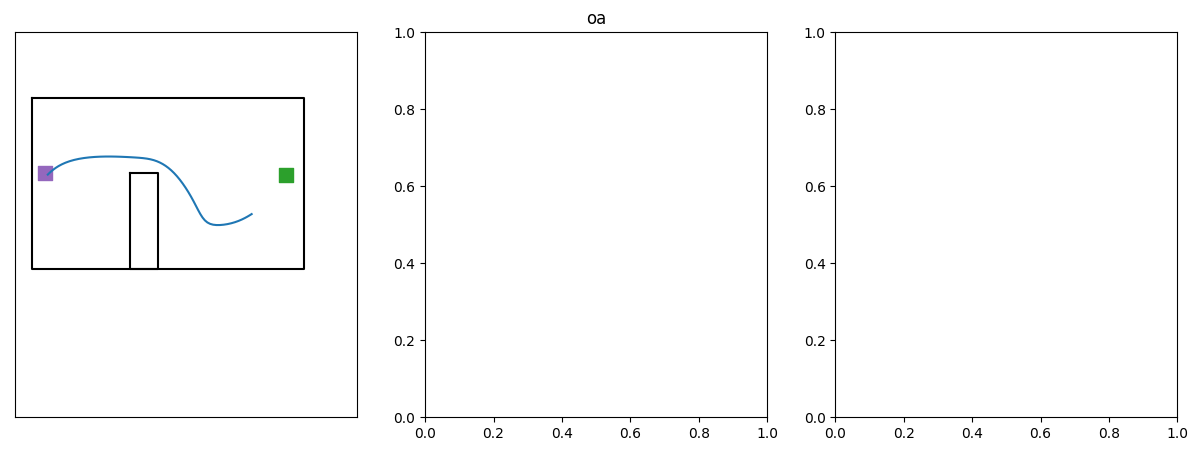

In [36]:
test = merg.sample(1)
#test = test[test.num_turn >= 3].sample(50)


for ind,row in test.iterrows():
    
        
    fig,ax = plt.subplots(1,3,figsize=(15,5))
    ax[0].set_xticks([])
    ax[0].set_yticks([])
   
    


    trial_df = test.loc[[ind]]
    plot_arena(test,ax[0])
    plot_orginal_obstacle(trial_df,ax[0],int(row.obstacle_cluster))



   
    ax[1].set_title(str(row.task) )
 


    

  
    ax[0].plot(row.ts_nose_x_cm,row.ts_nose_y_cm)
    

In [40]:
import cv2
import os

def extract_frames(video_path, frame_indices, output_dir):  
    """
    Extracts specified frames from a video and saves them as images.
    
    Parameters:
    - video_path (str): Path to the input video file.
    - frame_indices (list of int): List of frame indices to extract.
    - output_dir (str): Directory where the extracted frames will be saved.
    
    Returns:
    - None
    """
    # Check if the output directory exists, create if it doesn't
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("Error: Could not open video file.")
        return
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = [i for i in frame_indices if i < total_frames]  # Filter valid frame indices
    
    # Read each frame
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        success, frame = cap.read()
        
        if success:
            frame_filename = os.path.join(output_dir, f"frame_{idx}.png")
            cv2.imwrite(frame_filename, frame)
            print(f"Saved frame {idx} to {frame_filename}")
        else:
            print(f"Warning: Could not extract frame {idx}.")
    
    # Release the video capture object
    cap.release()
    print("Frame extraction completed.")

# Example usage
# video_path = "path/to/your/video.mp4"
# frame_indices = [10, 50, 100]  # Specify the frame indices to extract
# output_dir = "output_frames"
# extract_frames(video_path, frame_indices, output_dir)



In [55]:

extract_frames(r"D:\obstacle_avoidance\recordings\072523\G8CKLN\oa\072523_G8CKLN_whiteblack_Rig2_oa_top1.avi", trial_df.trial_vidframes.tolist()[0].tolist()[0], r"D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames")

Saved frame 4532 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4532.png
Saved frame 4533 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4533.png
Saved frame 4534 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4534.png
Saved frame 4535 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4535.png
Saved frame 4536 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4536.png
Saved frame 4537 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4537.png
Saved frame 4538 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4538.png
Saved frame 4539 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frames\frame_4539.png
Saved frame 4540 to D:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one\merg_frame

In [5]:
light_trial_permin = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_trial_permin.h5")

In [58]:
d:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_one

array(['oa', 'training', 'oa1'], dtype=object)

In [6]:
light_trial_permin

,animal,date,date_index,trialpermin,task,session_min,trials,trial_time
0,J701LT,030624,0.0,9.920298,oa,13.104444,130,5.250000
1,J701NN,030624,0.0,12.901412,oa,11.859167,153,4.100000
2,J701RN,030624,0.0,8.695864,oa,11.384722,99,5.616667
3,J701RT,030624,0.0,12.540078,oa,7.017500,88,4.266667
4,J701LT,030724,1.0,11.715976,oa,7.511111,88,4.400000
...,...,...,...,...,...,...,...,...
15,G8CK1TT,051523,-2.0,9.664594,oa,8.174167,79,4.350000
16,G8CK1LN,051623,-1.0,14.393968,oa,7.294722,105,2.966667
17,G8CK1LT,051623,-1.0,10.989886,oa,10.464167,115,3.483333
18,G8CK1RT,051623,-1.0,10.432721,oa,8.435000,88,3.216667


<AxesSubplot: xlabel='days', ylabel='trial duration (sec)'>

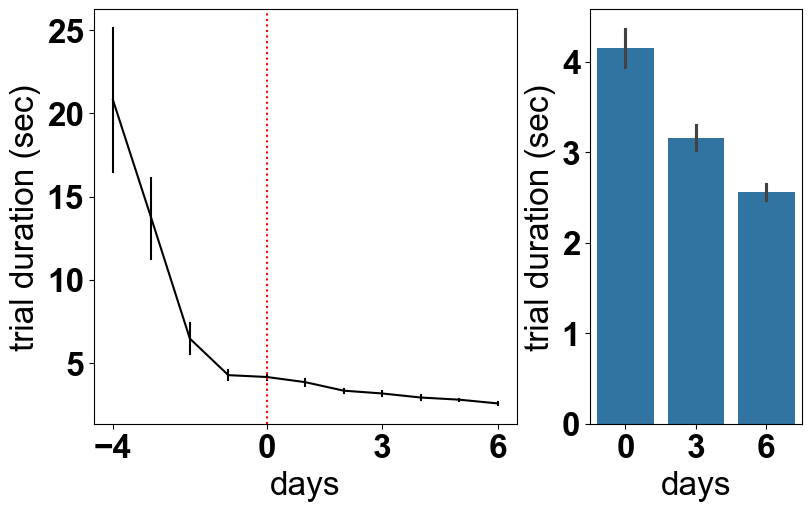

In [4]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trial duration (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel('trial duration (sec)')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trial_time' ,errorbar='se',err_style='bars',color = 'black')

bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
ax1.axvline(0, color='r', ls=':')
#ax1.text(0, ax1.get_ylim()[1]/2,'obstacle task start', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax1.set_xticks([-4,0,3,6])
   
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trial_time',errorbar = 'se')
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_time.pdf',dpi = 300)

(-0.5, 6.5)

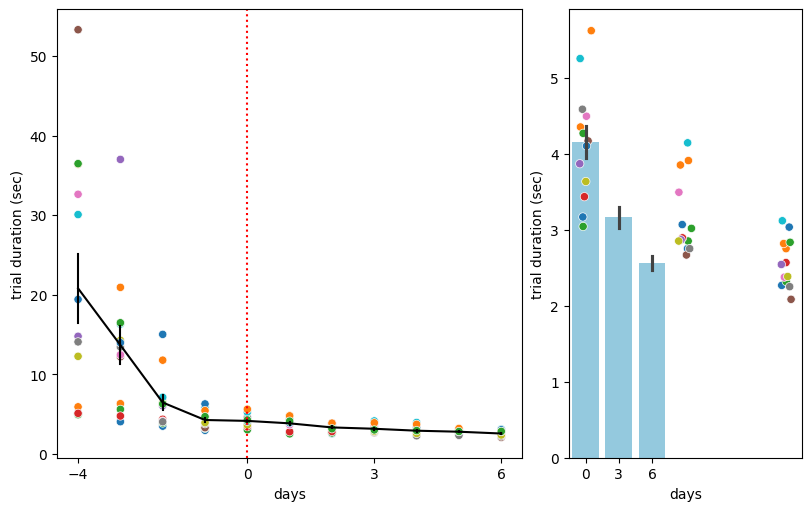

In [11]:
line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')
fig = plt.figure(layout="constrained", figsize=(8, 5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trial duration (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel('trial duration (sec)')

# Calculate individual animal means for the line plot
individual_means = line.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Create line plot with error bars
sns.lineplot(ax=ax1, data=line, x='date_index', y='trial_time', 
             errorbar='se', err_style='bars', color='black')

# Add individual animal means as scatter points
sns.scatterplot(ax=ax1, data=individual_means, x='date_index', y='trial_time', 
                hue='animal', legend=False, palette='tab10')

ax1.axvline(0, color='r', ls=':')
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index == 0.0) | 
                         (light_trial_permin.date_index == 6.0) | 
                         (light_trial_permin.date_index == 3.0)]

# Create bar plot
sns.barplot(ax=ax2, data=bar, x=bar.date_index.astype(int), y='trial_time', 
            errorbar='se', color='skyblue')

# Calculate individual animal means for the bar plot days
bar_individual_means = bar.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Add jitter to x positions for better visibility
bar_individual_means['jittered_x'] = bar_individual_means['date_index'].astype(int) + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))

# Add individual animal means as scatter points to bar plot
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trial_time', 
                hue='animal', legend=False, palette='tab10')

# Adjust x-axis limits for bar plot to accommodate jittered points
ax2.set_xlim(-0.5, 6.5)

(-0.5, 2.5)

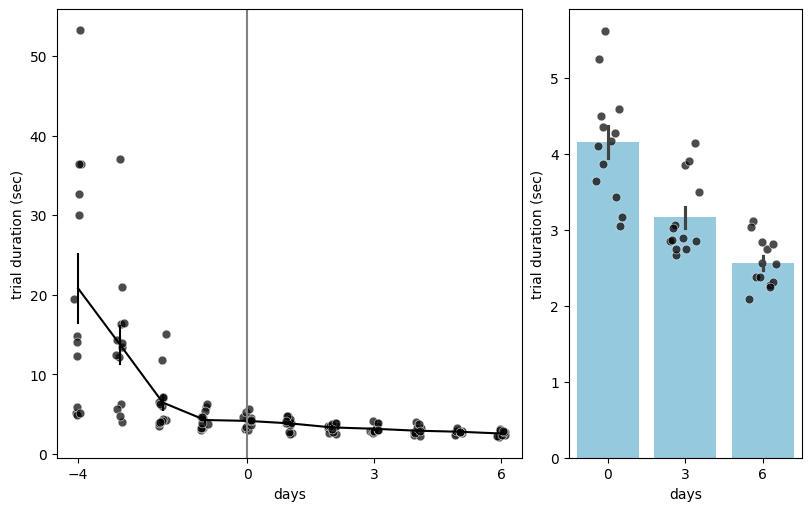

In [15]:
line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')
fig = plt.figure(layout="constrained", figsize=(8, 5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trial duration (sec)')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel('trial duration (sec)')

# Calculate individual animal means for the line plot
individual_means = line.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Add jitter to x positions for line plot (smaller jitter range)
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Create line plot with error bars
sns.lineplot(ax=ax1, data=line, x='date_index', y='trial_time', 
             errorbar='se', err_style='bars', color='black')

# Add individual animal means as scatter points (light blue)
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trial_time', 
                color='black', s=40, alpha=0.7)

ax1.axvline(0, color='grey', ls='-')
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index == 0.0) | 
                         (light_trial_permin.date_index == 6.0) | 
                         (light_trial_permin.date_index == 3.0)]

# Create bar plot
sns.barplot(ax=ax2, data=bar, x='date_index', y='trial_time', 
            errorbar='se', color='skyblue')

# Calculate individual animal means for the bar plot days
bar_individual_means = bar.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Create a mapping from date_index to x-position (since barplot uses categorical positions)
date_to_pos = {0.0: 0, 3.0: 1, 6.0: 2}  # Adjust based on your actual bar positions

# Add jitter to x positions for bar plot (centered on each bar)
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))

# Add individual animal means as scatter points to bar plot (light blue)
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trial_time', 
                color='black', s=40, alpha=0.7)

# Set proper x-tick labels for bar plot
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels([0, 3, 6])

# Adjust x-axis limits for both plots
ax1.set_xlim(-4.5, 6.5)
ax2.set_xlim(-0.5, 2.5)

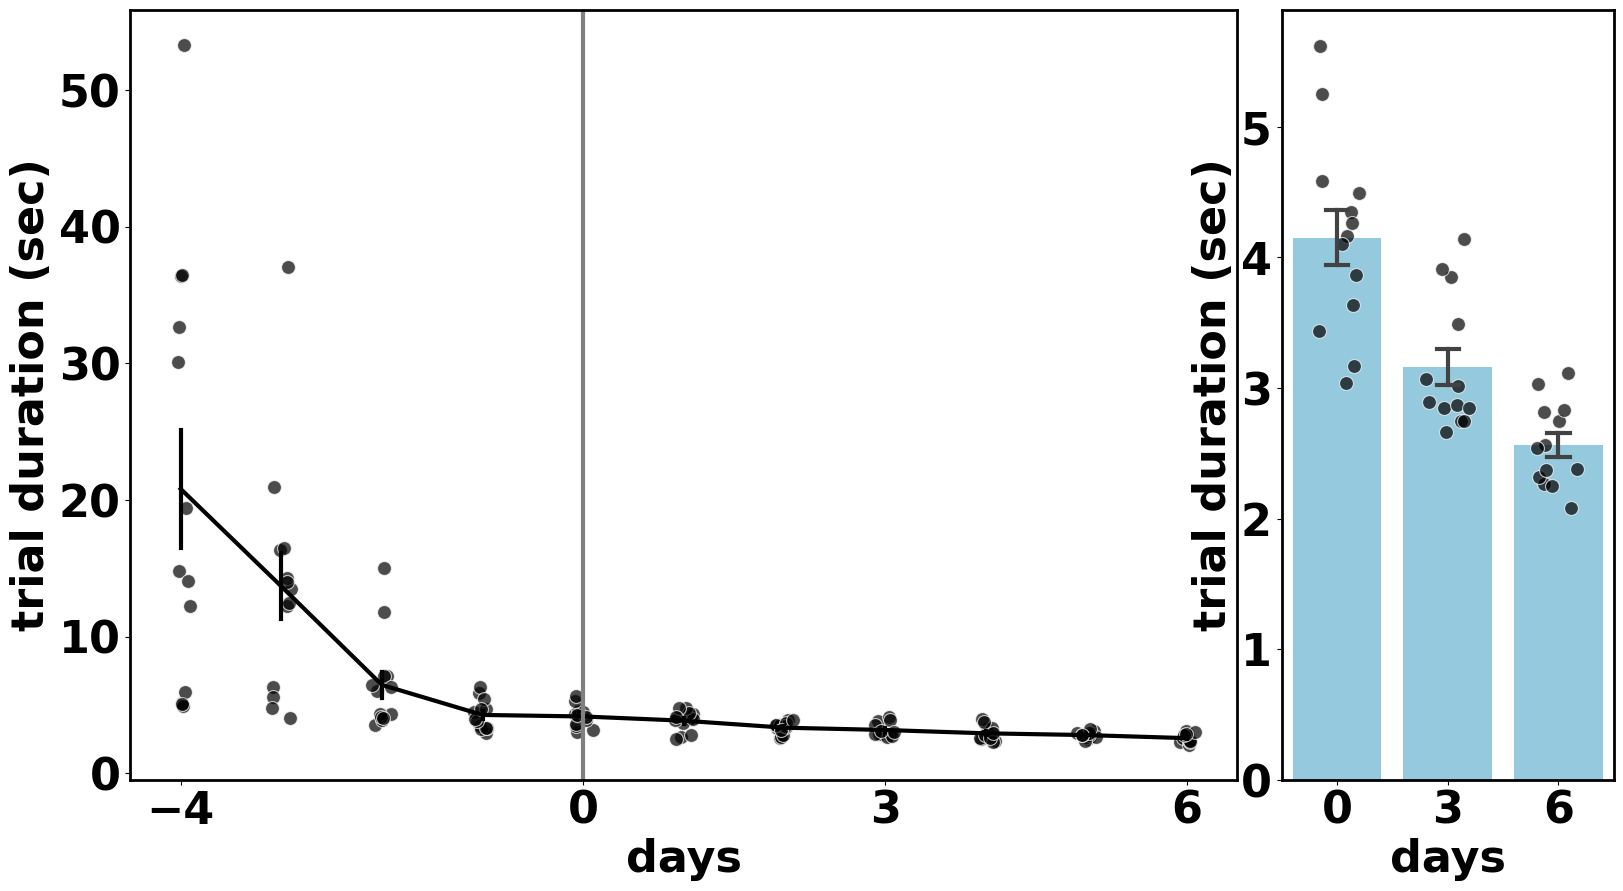

In [3]:
# Set global font properties
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2  # Thicker axes lines
})

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
#plt.rc('axes', edgecolor='black')

# Create larger figure with width ratio adjusted for more space between subplots
fig = plt.figure( figsize=(20, 10))  # Increased from (8,5) to (20,10)

# Use width_ratios to create more space between subplots
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.2, 0.1, 0.1, 1.5, 0.1])  # Added empty columns for spacing
ax1 = fig.add_subplot(gs[0, 0:4])  # Left plot
ax2 = fig.add_subplot(gs[0, 4:5])  # Right plot (shifted right with space in between)

# Set labels with bold font
ax1.set_xlabel('days', fontweight='bold')
ax1.set_ylabel('trial duration (sec)', fontweight='bold')
ax2.set_xlabel('days', fontweight='bold')
ax2.set_ylabel('trial duration (sec)', fontweight='bold')

# Calculate individual animal means for the line plot
individual_means = line.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Add jitter to x positions for line plot
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Create line plot with thicker error bars
sns.lineplot(ax=ax1, data=line, x='date_index', y='trial_time', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})

# Add individual animal means as scatter points with larger markers
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trial_time', 
                color='black', s=100, alpha=0.7)  # Increased from s=40 to s=100

# Vertical line with thicker width
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index == 0.0) | 
                         (light_trial_permin.date_index == 6.0) | 
                         (light_trial_permin.date_index == 3.0)]

# Create bar plot with thicker error bars
sns.barplot(ax=ax2, data=bar, x='date_index', y='trial_time', 
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Calculate individual animal means for the bar plot days
bar_individual_means = bar.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Create a mapping from date_index to x-position
date_to_pos = {0.0: 0, 3.0: 1, 6.0: 2}

# Add jitter to x positions for bar plot
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))

# Add individual animal means as scatter points with larger markers
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trial_time', 
                color='black', s=100, alpha=0.7)  # Increased from s=40 to s=100

# Set proper x-tick labels for bar plot
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels([0, 3, 6])

# Adjust x-axis limits for both plots
ax1.set_xlim(-4.5, 6.5)
ax2.set_xlim(-0.5, 2.5)

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout with more padding
plt.tight_layout(pad=20.0)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_duration.pdf',dpi = 300)

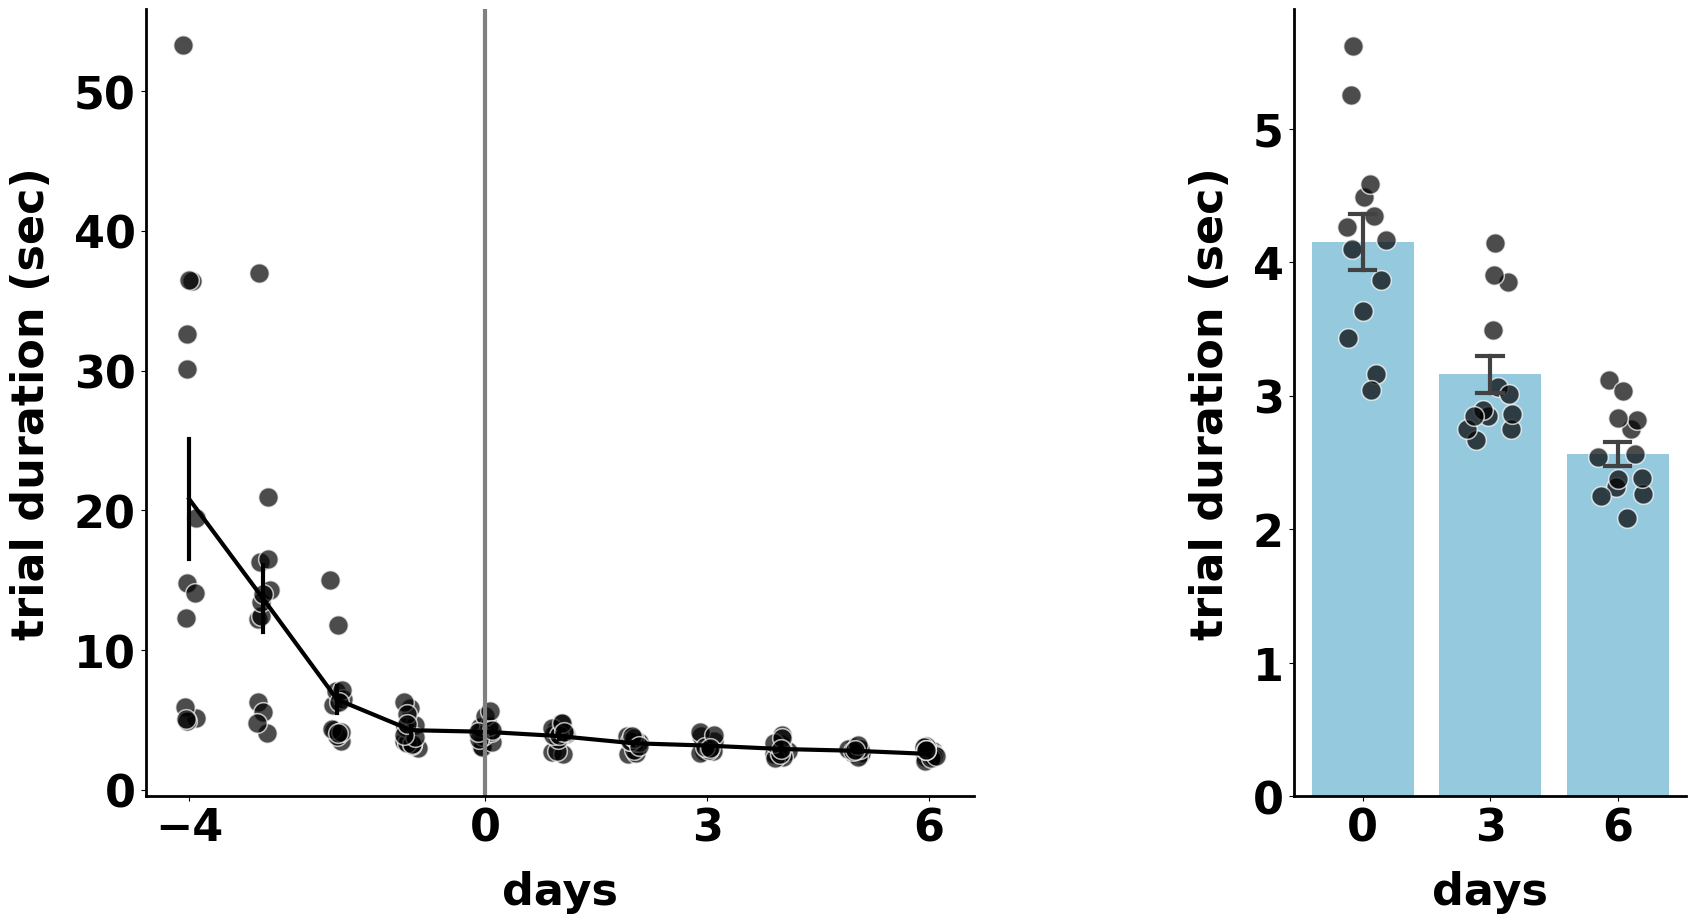

In [17]:
# Set global font properties

plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create larger figure
fig = plt.figure(figsize=(20, 10))

# Use GridSpec with adjusted spacing - now with more space for y-axis labels
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])  # Added more space on both sides
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 3:5], sharey=None)  # Explicitly no shared axis

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='bold', labelpad=15)
ax1.set_ylabel('trial duration (sec)', fontweight='bold', labelpad=15)
ax2.set_xlabel('days', fontweight='bold', labelpad=15)
ax2.set_ylabel('trial duration (sec)', fontweight='bold', labelpad=15)  # Keep y-label for second plot

# Calculate individual animal means
individual_means = line.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Line plot
sns.lineplot(ax=ax1, data=line, x='date_index', y='trial_time', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trial_time', 
                color='black', s=200, alpha=0.7)
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data
bar = light_trial_permin[(light_trial_permin.date_index.isin([0.0, 3.0, 6.0]))]
bar_individual_means = bar.groupby(['date_index', 'animal'])['trial_time'].mean().reset_index()

# Bar plot - now with independent y-axis
sns.barplot(ax=ax2, data=bar, x='date_index', y='trial_time', 
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Add jittered points
date_to_pos = {0.0: 0, 3.0: 1, 6.0: 2}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trial_time', 
                color='black', s=200, alpha=0.7)

# Adjust bar plot ticks
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels([0, 3, 6])

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout with even more space between plots
plt.subplots_adjust(wspace=1.0)  # Increased space between subplots
plt.tight_layout()
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_duration.pdf',dpi = 300)

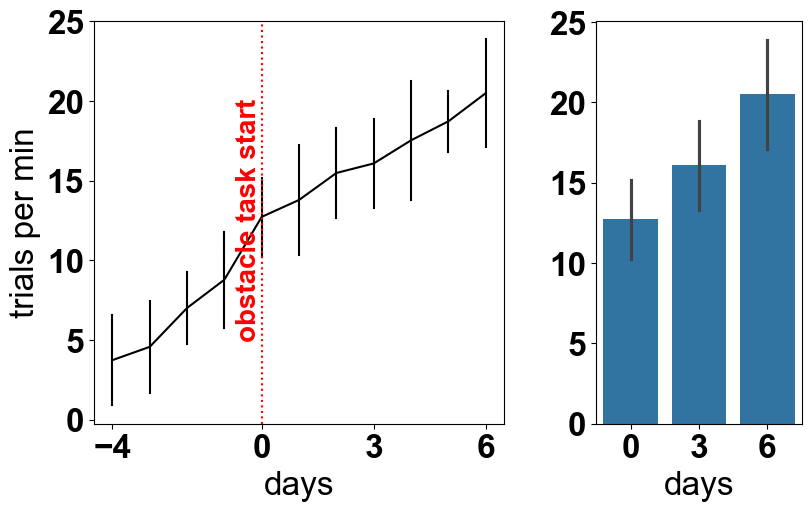

In [62]:

line = light_trial_permin[(light_trial_permin.date_index >=-4) & (light_trial_permin.date_index <=6)]
plt.rc('axes',edgecolor='black')
fig = plt.figure(layout="constrained",figsize = (8,5))

gs = GridSpec(1, 6, figure=fig)
ax1 = fig.add_subplot(gs[0, 0:4])
ax1.set_xlabel('days')
ax1.set_ylabel('trials per min')
ax2 = fig.add_subplot(gs[0, 4:])
ax2.set_xlabel('days')
ax2.set_ylabel(' ')


sns.lineplot(ax = ax1, data =line,x = 'date_index',y='trialpermin' ,errorbar='sd',err_style='bars',color = 'black')
ax1.set_xticks([-4,0,3,6])
   
bar =  light_trial_permin[(light_trial_permin.date_index == 0.0 ) | (light_trial_permin.date_index ==6.0)| (light_trial_permin.date_index ==3.0)]
sns.barplot(ax = ax2, data =bar,x = bar.date_index.astype(int),y='trialpermin',errorbar = 'sd')
ax1.axvline(0, color='r', ls=':')
ax1.text(0, ax1.get_ylim()[1]/2,'obstacle task start', color='r', ha='right', va='center', rotation=90,fontsize=20)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_permin.pdf',dpi = 300)

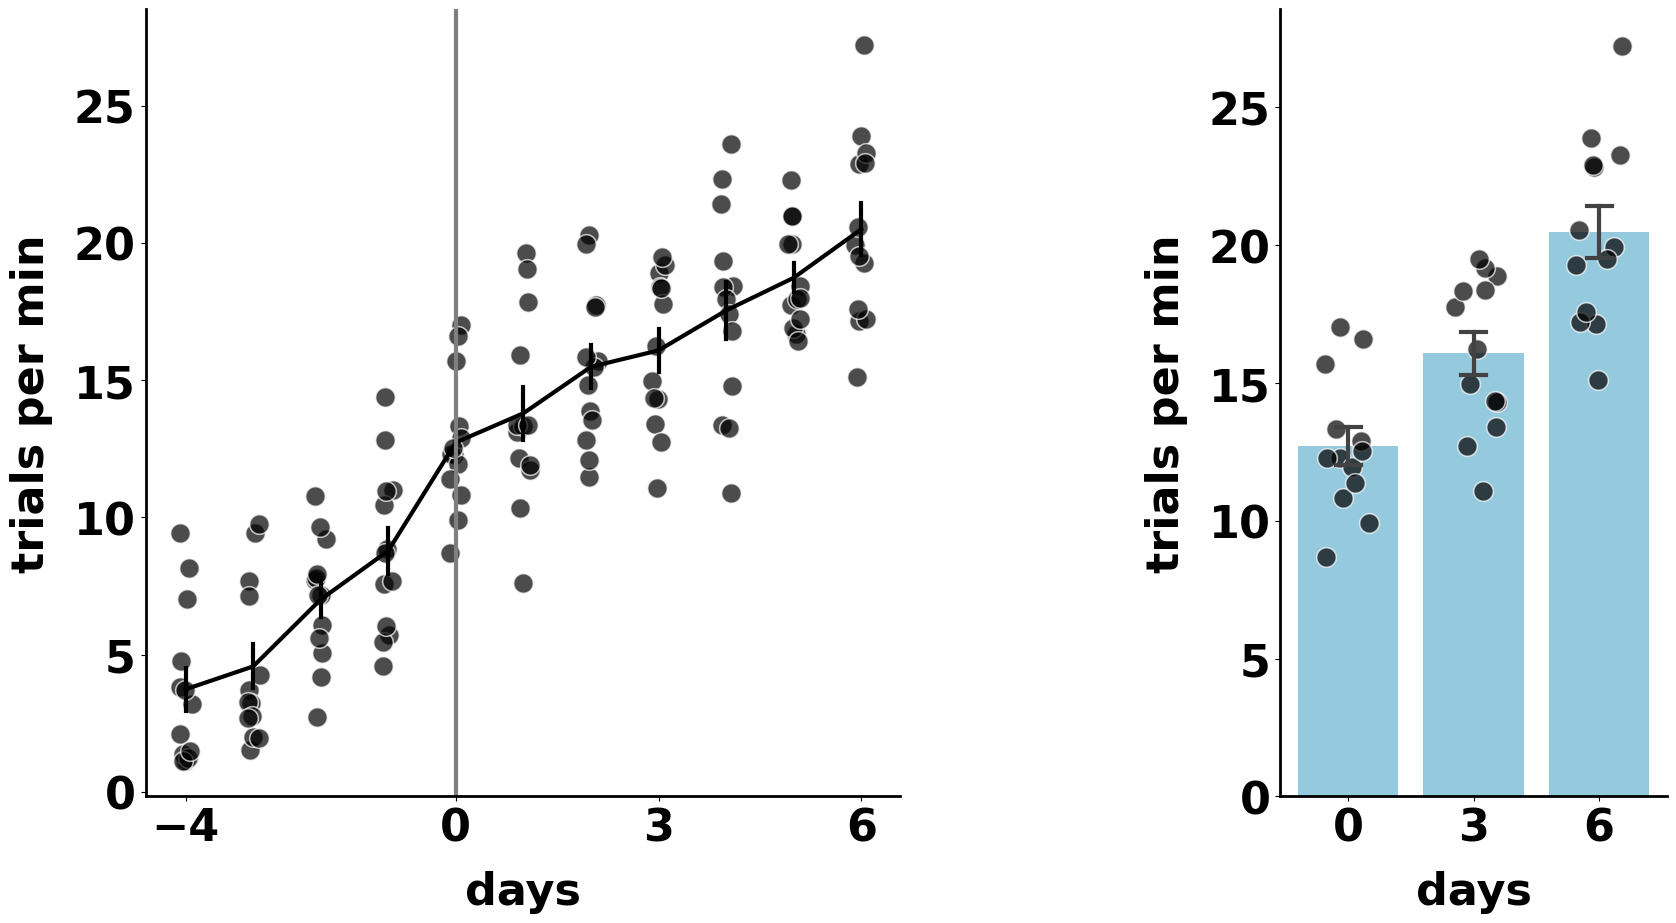

In [19]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2
})

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create larger figure
fig = plt.figure(figsize=(20, 10))

# Use GridSpec with adjusted spacing - now with more space for y-axis labels
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])  # Added more space on both sides
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 3:5], sharey=None)  # Explicitly no shared axis

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='bold', labelpad=15)
ax1.set_ylabel('trials per min', fontweight='bold', labelpad=15)  # Changed to trials per min
ax2.set_xlabel('days', fontweight='bold', labelpad=15)
ax2.set_ylabel('trials per min', fontweight='bold', labelpad=15)  # Changed to trials per min

# Calculate individual animal means using trialpermin
individual_means = line.groupby(['date_index', 'animal'])['trialpermin'].mean().reset_index()  # Changed to trialpermin
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Line plot using trialpermin
sns.lineplot(ax=ax1, data=line, x='date_index', y='trialpermin',  # Changed to trialpermin
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trialpermin',  # Changed to trialpermin
                color='black', s=200, alpha=0.7)
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data using trialpermin
bar = light_trial_permin[(light_trial_permin.date_index.isin([0.0, 3.0, 6.0]))]
bar_individual_means = bar.groupby(['date_index', 'animal'])['trialpermin'].mean().reset_index()  # Changed to trialpermin

# Bar plot using trialpermin
sns.barplot(ax=ax2, data=bar, x='date_index', y='trialpermin',  # Changed to trialpermin
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Add jittered points
date_to_pos = {0.0: 0, 3.0: 1, 6.0: 2}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trialpermin',  # Changed to trialpermin
                color='black', s=200, alpha=0.7)

# Adjust bar plot ticks
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels([0, 3, 6])

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout
plt.subplots_adjust(wspace=1.0)
plt.tight_layout()     

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_permin.pdf',dpi = 300)

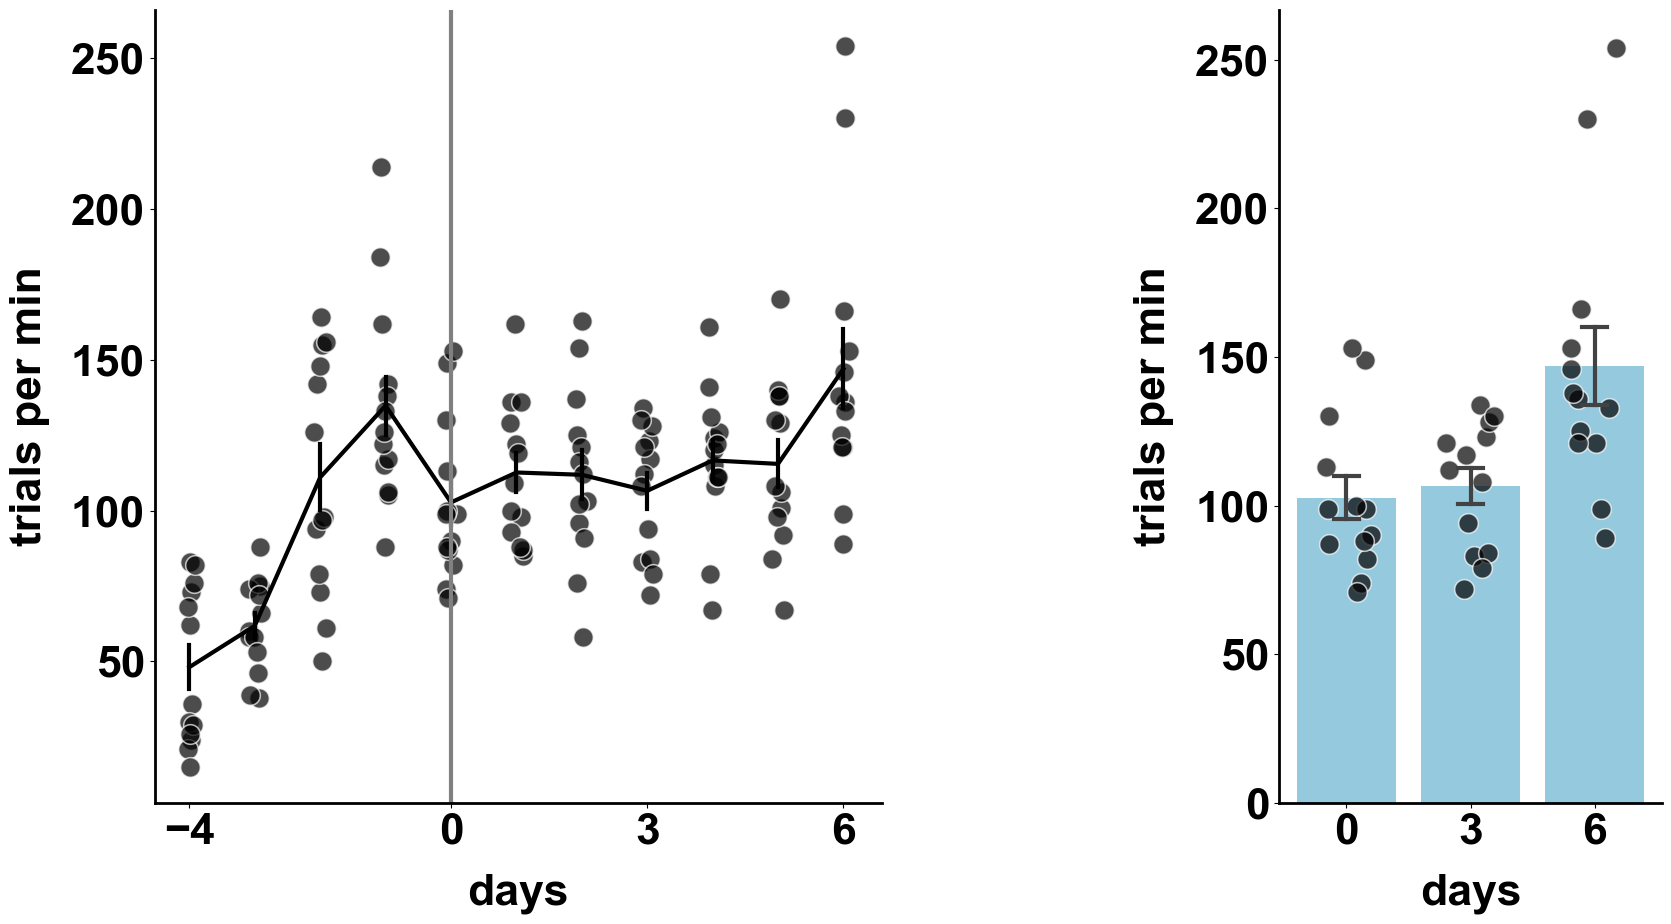

In [7]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'bold',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2
})

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create larger figure
fig = plt.figure(figsize=(20, 10))

# Use GridSpec with adjusted spacing - now with more space for y-axis labels
gs = GridSpec(1, 6, figure=fig, width_ratios=[4, 0.5, 0.1, 0.1, 1.5, 0.5])  # Added more space on both sides
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 3:5], sharey=None)  # Explicitly no shared axis

# Remove top and right spines
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='bold', labelpad=15)
ax1.set_ylabel('trials per min', fontweight='bold', labelpad=15)  # Changed to trials per min
ax2.set_xlabel('days', fontweight='bold', labelpad=15)
ax2.set_ylabel('trials per min', fontweight='bold', labelpad=15)  # Changed to trials per min

# Calculate individual animal means using trials
individual_means = line.groupby(['date_index', 'animal'])['trials'].mean().reset_index()  # Changed to trials
individual_means['jittered_x'] = individual_means['date_index'] + np.random.uniform(-0.1, 0.1, size=len(individual_means))

# Line plot using trials
sns.lineplot(ax=ax1, data=line, x='date_index', y='trials',  # Changed to trials
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})
sns.scatterplot(ax=ax1, data=individual_means, x='jittered_x', y='trials',  # Changed to trials
                color='black', s=200, alpha=0.7)
ax1.axvline(0, color='grey', ls='-', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Bar plot data using trials
bar = light_trial_permin[(light_trial_permin.date_index.isin([0.0, 3.0, 6.0]))]
bar_individual_means = bar.groupby(['date_index', 'animal'])['trials'].mean().reset_index()  # Changed to trials

# Bar plot using trials
sns.barplot(ax=ax2, data=bar, x='date_index', y='trials',  # Changed to trials
            errorbar='se', color='skyblue', 
            errwidth=3, linewidth=3, capsize=0.2)

# Add jittered points
date_to_pos = {0.0: 0, 3.0: 1, 6.0: 2}
bar_individual_means['x_pos'] = bar_individual_means['date_index'].map(date_to_pos)
bar_individual_means['jittered_x'] = bar_individual_means['x_pos'] + np.random.uniform(-0.2, 0.2, size=len(bar_individual_means))
sns.scatterplot(ax=ax2, data=bar_individual_means, x='jittered_x', y='trials',  # Changed to trials
                color='black', s=200, alpha=0.7)

# Adjust bar plot ticks
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels([0, 3, 6])

# Make all text bold
for ax in [ax1, ax2]:
    for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
                 ax.get_xticklabels() + ax.get_yticklabels()):
        item.set_fontweight('bold')

# Adjust layout
plt.subplots_adjust(wspace=1.0)
plt.tight_layout()     

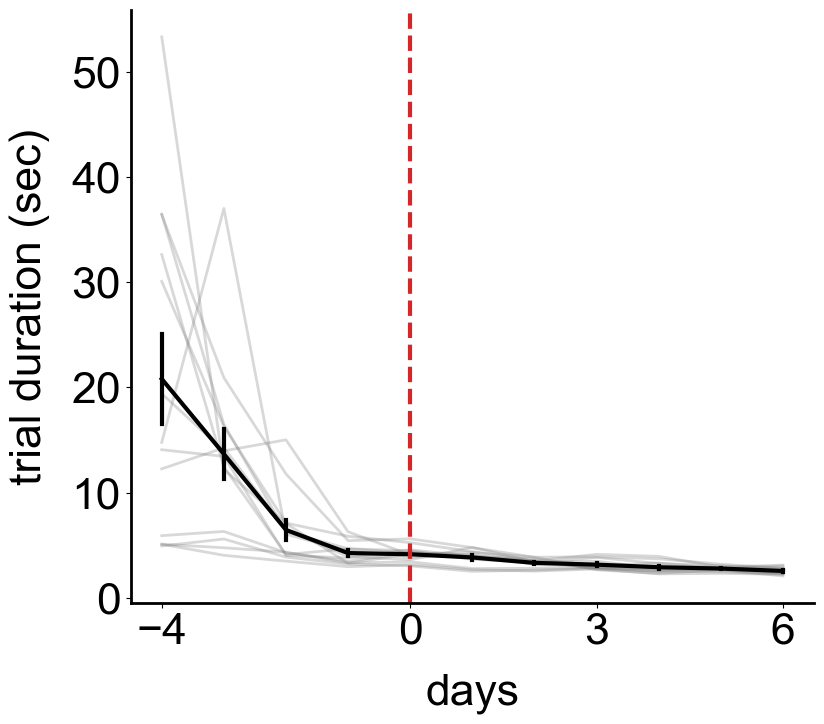

meta NOT subset; don't know how to subset; dropped


In [17]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('trial duration (sec)', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Plot individual animal lines with low alpha in grey
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trial_time for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trial_time'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trial_time'], 
             color='grey', alpha=0.3, linewidth=2)

# Main line plot (group average)
sns.lineplot(ax=ax1, data=line, x='date_index', y='trial_time', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()
plt.show()
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_duration_new.pdf',dpi = 300)

In [7]:
light_trial_permin

,animal,date,date_index,trialpermin,task,session_min,trials,trial_time
0,J701LT,030624,0.0,9.920298,oa,13.104444,130,5.250000
1,J701NN,030624,0.0,12.901412,oa,11.859167,153,4.100000
2,J701RN,030624,0.0,8.695864,oa,11.384722,99,5.616667
3,J701RT,030624,0.0,12.540078,oa,7.017500,88,4.266667
4,J701LT,030724,1.0,11.715976,oa,7.511111,88,4.400000
...,...,...,...,...,...,...,...,...
15,G8CK1TT,051523,-2.0,9.664594,oa,8.174167,79,4.350000
16,G8CK1LN,051623,-1.0,14.393968,oa,7.294722,105,2.966667
17,G8CK1LT,051623,-1.0,10.989886,oa,10.464167,115,3.483333
18,G8CK1RT,051623,-1.0,10.432721,oa,8.435000,88,3.216667


meta NOT subset; don't know how to subset; dropped


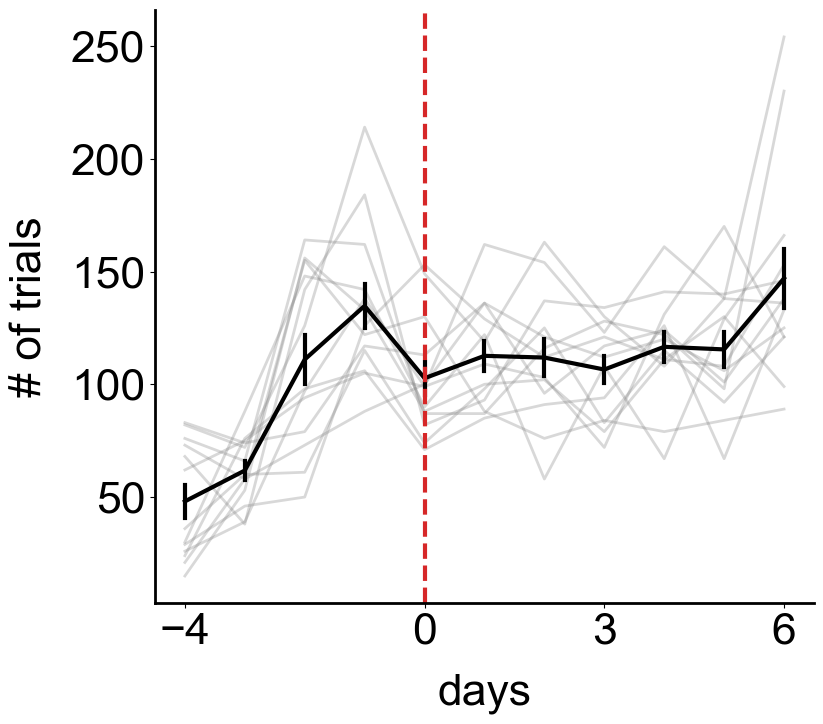

In [17]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('# of trials', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Plot individual animal lines with low alpha in grey
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trials for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trials'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trials'], 
             color='grey', alpha=0.3, linewidth=2)

# Main line plot (group average)
sns.lineplot(ax=ax1, data=line, x='date_index', y='trials', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trial_#_new.pdf',dpi = 300)
plt.show()

meta NOT subset; don't know how to subset; dropped


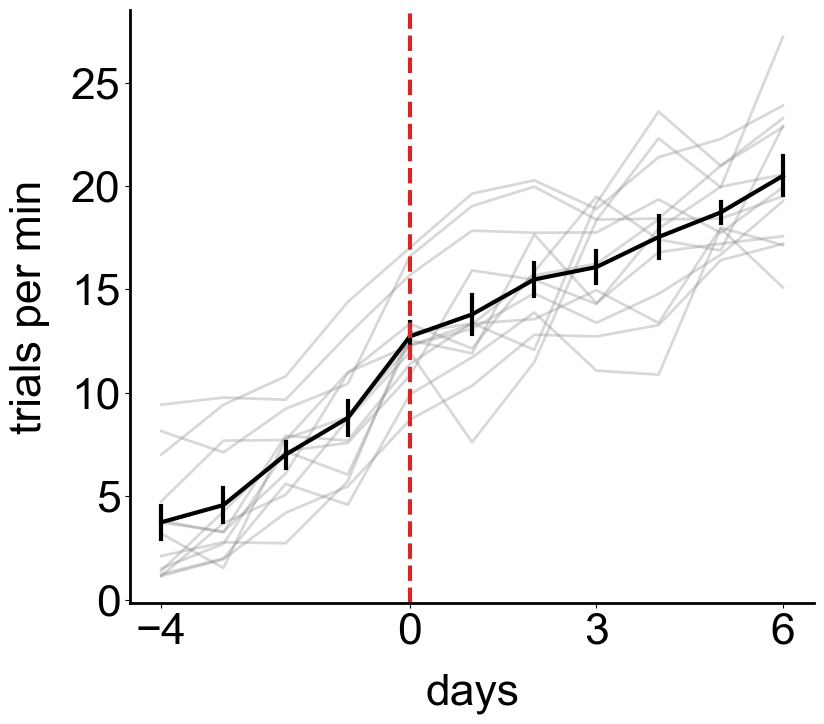

In [16]:
# Set global font properties
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',  # Transparent figure background
    'savefig.transparent': True  # Ensure saved files maintain transparency
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

line = light_trial_permin[(light_trial_permin.date_index >= -4) & (light_trial_permin.date_index <= 6)]
plt.rc('axes', edgecolor='black')

# Create figure with only one subplot
fig, ax1 = plt.subplots(1, 1, figsize=(9, 8))

# Remove top and right spines
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(2)
ax1.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax1.set_xlabel('days', fontweight='normal', labelpad=15)
ax1.set_ylabel('trials per min', fontweight='normal', labelpad=15)

# Get unique animals
unique_animals = line['animal'].unique()

# Plot individual animal lines with low alpha in grey
for animal in unique_animals:
    animal_data = line[line['animal'] == animal]
    # Calculate mean trialpermin for each date_index for this animal
    animal_means = animal_data.groupby('date_index')['trialpermin'].mean().reset_index()
    ax1.plot(animal_means['date_index'], animal_means['trialpermin'], 
             color='grey', alpha=0.3, linewidth=2)

# Main line plot (group average)
sns.lineplot(ax=ax1, data=line, x='date_index', y='trialpermin', 
             errorbar='se', err_style='bars', color='black', 
             linewidth=3, err_kws={'linewidth': 3})

# Add vertical line at day 0
ax1.axvline(0, color='tab:red', ls='--', linewidth=3)
ax1.set_xticks([-4, 0, 3, 6])

# Make all text normal
for item in ([ax1.title, ax1.xaxis.label, ax1.yaxis.label] +
             ax1.get_xticklabels() + ax1.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trialpermin_new.pdf',dpi = 300)
plt.show()

meta NOT subset; don't know how to subset; dropped


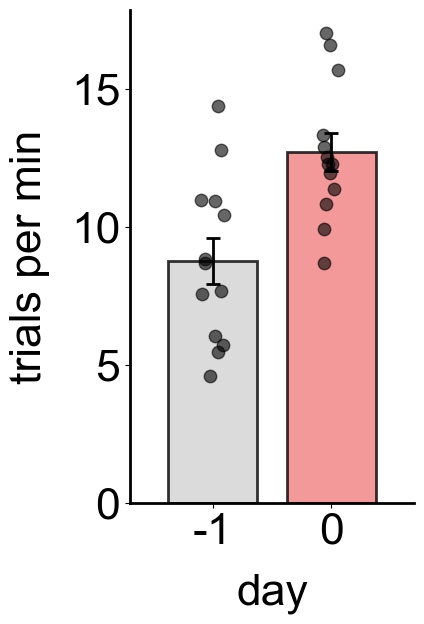

Summary Statistics:
Day -1: Mean = 8.78 ± 0.83 SEM, SD = 3.00, n = 13
Day 0: Mean = 12.73 ± 0.69 SEM, SD = 2.47, n = 13


In [29]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure
fig, ax = plt.subplots(1, 1, figsize=(5, 7))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('trials per min', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5 (closer than before)
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Smaller jitter since bars are closer

# Plot individual scatter points for each animal
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean for this animal on this day
            animal_mean = animal_day_data['trialpermin'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trialpermin'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = .75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'lightgrey'
    else:
        bar_color = 'lightcoral'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)

# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trialpermin_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

In [1]:
# Filter data for day -1 and 0
bar_data = light_trial_permin[(light_trial_permin.date_index.isin([-1, 0]))]

# Prepare figure with consistent font settings
plt.rcParams.update({
    'font.size': 32,
    'font.weight': 'normal',
    'axes.titlesize': 32,
    'axes.labelsize': 32,
    'xtick.labelsize': 32,
    'ytick.labelsize': 32,
    'axes.linewidth': 2,
    'figure.facecolor': 'none',
    'savefig.transparent': True
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rc('axes', edgecolor='black')

fig, ax = plt.subplots(1, 1, figsize=(6, 8))

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# Set labels with padding
ax.set_xlabel('day', fontweight='normal', labelpad=15)
ax.set_ylabel('# of trials', fontweight='normal', labelpad=15)

# Create custom x positions for the bars (closer together)
x_positions = [0.5, 1.5]  # Day -1 at position 0.5, Day 0 at position 1.5
x_labels = ['-1', '0']

# Get unique animals
unique_animals = bar_data['animal'].unique()

# Create jitter for scatter points
np.random.seed(42)  # For reproducibility
jitter = 0.1  # Small jitter

# Plot individual scatter points for each animal
for i, day in enumerate([-1, 0]):
    day_data = bar_data[bar_data['date_index'] == day]
    
    for animal in unique_animals:
        animal_day_data = day_data[day_data['animal'] == animal]
        if not animal_day_data.empty:
            # Calculate mean trials for this animal on this day
            animal_mean = animal_day_data['trials'].mean()
            
            # Add small jitter to x-position
            x_jitter = x_positions[i] + np.random.uniform(-jitter, jitter)
            
            # Plot grey scatter point
            ax.scatter(x_jitter, animal_mean, color='black', s=80, 
                      alpha=0.6, edgecolor='black', linewidth=1, zorder=3)

# Calculate group means and standard errors for bars
group_stats = bar_data.groupby('date_index')['trials'].agg(['mean', 'sem', 'std']).reset_index()

# Plot bars (closer together with narrower width)
bar_width = 0.75  # Narrower bars for closer spacing

for i, (_, row) in enumerate(group_stats.iterrows()):
    x_pos = x_positions[0] if row['date_index'] == -1 else x_positions[1]
    
    # Plot bars with different colors for each day
    if row['date_index'] == -1:
        bar_color = 'tab:green'
    else:
        bar_color = 'tab:blue'
    
    ax.bar(x_pos, row['mean'], width=bar_width, color=bar_color, 
           edgecolor='black', linewidth=2, alpha=0.8, zorder=2)
    
    # Add error bars (SEM)
    ax.errorbar(x_pos, row['mean'], yerr=row['sem'], color='black', 
                capsize=5, capthick=2, linewidth=2, fmt='none', zorder=4)

# Set x-ticks and labels
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)

# Set x-axis limits to bring bars closer to center
ax.set_xlim(x_positions[0] - 0.7, x_positions[1] + 0.7)


# Make all text normal
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontweight('normal')

plt.tight_layout()

# Save figure
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\trials_day_minus1_0.pdf', dpi=300, transparent=True)
plt.show()

# Print summary statistics
print("Summary Statistics:")
for i, (_, row) in enumerate(group_stats.iterrows()):
    day_label = "Day -1" if row['date_index'] == -1 else "Day 0"
    n_animals = len(bar_data[bar_data['date_index'] == row['date_index']]['animal'].unique())
    print(f"{day_label}: Mean = {row['mean']:.2f} ± {row['sem']:.2f} SEM, SD = {row['std']:.2f}, n = {n_animals}")

NameError: name 'light_trial_permin' is not defined